worksheet 1

Image Processing and PCA Image Compression

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Read and display the image

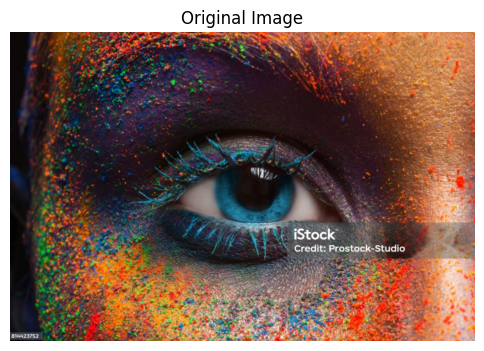

In [58]:
# Load image
img = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png")
image_array = np.array(img)

# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")
plt.show()


Display top-left 100x100 pixels

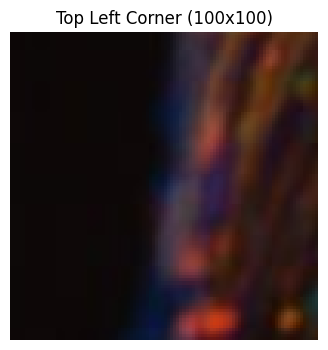

In [59]:
# Extract top-left 100x100 pixels
top_left = image_array[:100, :100]

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

Show R, G, B channels

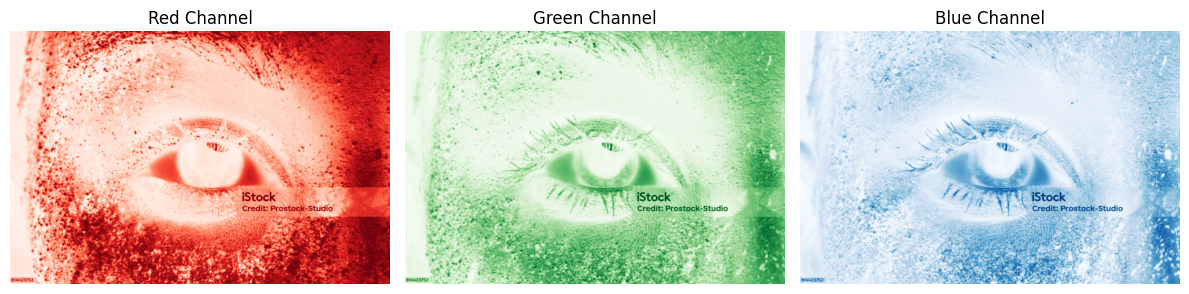

In [60]:
# Separate RGB channels
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

# Display RGB channels
plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(red_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(green_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blue_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

Modify top-left 100x100 pixels to 210

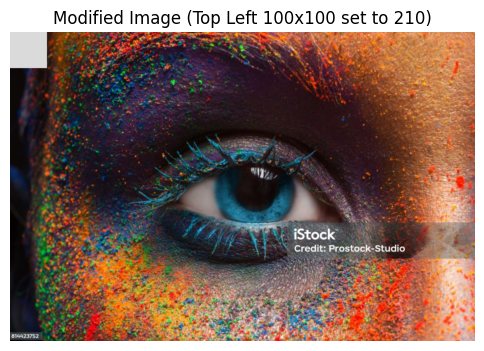

In [61]:
# Modify top-left 100x100 region to 210
modified_image = image_array.copy()
modified_image[:100, :100] = 210

plt.figure(figsize=(6, 6))
plt.imshow(modified_image)
plt.title("Modified Image (Top Left 100x100 set to 210)")
plt.axis("off")
plt.show()

Load and display grayscale image

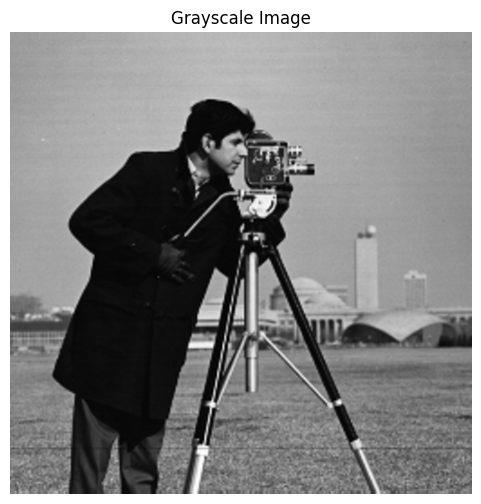

In [62]:
# Load grayscale image
gray_image = Image.open("/content/drive/MyDrive/AI ML/Data/cameraman.png").convert("L")
gray_array = np.array(gray_image)

# Display grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Extract middle 150-pixel section

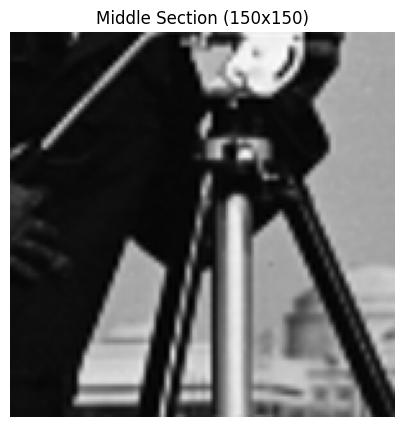

In [63]:
# Extract middle 150x150 section
height, width = gray_array.shape
center_y = height // 2
center_x = width // 2

half_size = 75  # 75 on each side gives 150x150 section

middle_section = gray_array[center_y - half_size:center_y + half_size,
                            center_x - half_size:center_x + half_size]

plt.figure(figsize=(5, 5))
plt.imshow(middle_section, cmap="gray")
plt.title("Middle Section (150x150)")
plt.axis("off")
plt.show()

Apply threshold

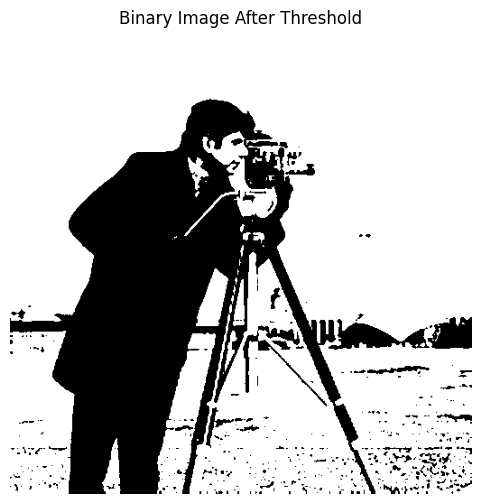

In [64]:
# Apply threshold
# Below 100 -> 0, Above or equal to 100 -> 255
binary_image = np.where(gray_array < 100, 0, 255)

plt.figure(figsize=(6, 6))
plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image After Threshold")
plt.axis("off")
plt.show()

Rotate 90 degrees clockwise

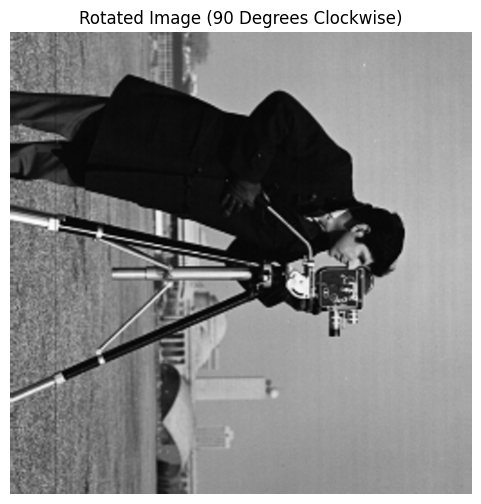

In [65]:
# Rotate 90 degrees clockwise
rotated_image = gray_image.transpose(Image.Transpose.ROTATE_270)
rotated_array = np.array(rotated_image)

plt.figure(figsize=(6, 6))
plt.imshow(rotated_array, cmap="gray")
plt.title("Rotated Image (90 Degrees Clockwise)")
plt.axis("off")
plt.show()

Convert grayscale to RGB

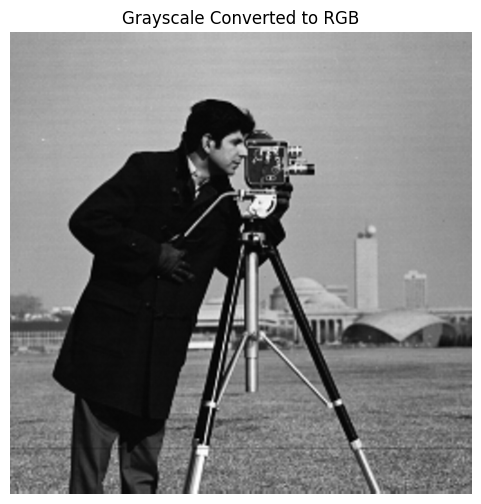

In [66]:
# Convert grayscale to RGB
rgb_from_gray = np.stack((gray_array, gray_array, gray_array), axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_from_gray)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

PCA Image Compression and Decompression

PCA from scratch for image compression

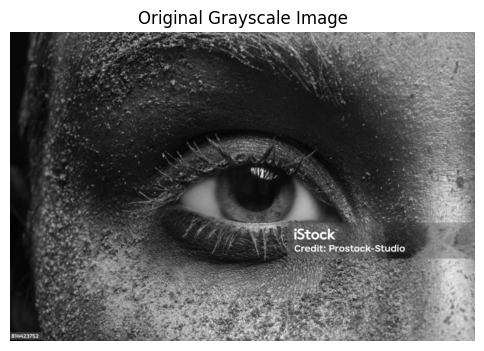

Image shape: (836, 1258)


In [67]:
# Load an image of your choice
pca_image = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png").convert("L")
img = np.array(pca_image, dtype=np.float64)

# Display original grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Image shape:", img.shape)

In [68]:
# For PCA on images, centering is the main required step.

mean_vector = np.mean(img, axis=0)
img_centered = img - mean_vector

print("Mean vector shape:", mean_vector.shape)
print("Centered image shape:", img_centered.shape)

Mean vector shape: (1258,)
Centered image shape: (836, 1258)


Covariance Matrix

In [69]:
#Covariance Matrix
cov_matrix = np.cov(img_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (1258, 1258)


Eigen Decomposition

In [70]:
#Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_index = np.argsort(eigen_values)[::-1]
sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

print("Eigenvalues shape:", sorted_eigenvalues.shape)
print("Eigenvectors shape:", sorted_eigenvectors.shape)

Eigenvalues shape: (1258,)
Eigenvectors shape: (1258, 1258)


Explained Variance

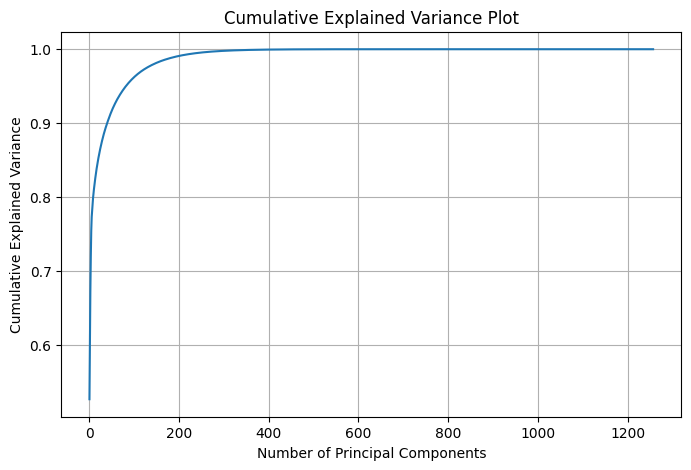

In [71]:
#Explained Variance
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

In [72]:
# Function to find k for a target explained variance
def find_k_for_variance(cumulative_variance, threshold):
    return np.argmax(cumulative_variance >= threshold) + 1

k_90 = find_k_for_variance(cumulative_variance, 0.90)
k_95 = find_k_for_variance(cumulative_variance, 0.95)
k_99 = find_k_for_variance(cumulative_variance, 0.99)

print("Components for 90% variance:", k_90)
print("Components for 95% variance:", k_95)
print("Components for 99% variance:", k_99)

Components for 90% variance: 41
Components for 95% variance: 83
Components for 99% variance: 194


Reconstruction Function

In [73]:
#Reconstruction Function
def pca_reconstruct(centered_data, mean_vector, eigenvectors, k):
    #Reconstruct an image using top-k principal components.

    principal_components = eigenvectors[:, :k]
    compressed_data = np.dot(centered_data, principal_components)
    reconstructed_data = np.dot(compressed_data, principal_components.T) + mean_vector
    return reconstructed_data

Experiment with Four Different k Values

In [74]:
#Experiment with Four Different k Values
k_values = [10, 20, 50, 100]   # You can change these if needed

reconstructed_images = []

for k in k_values:
    reconstructed = pca_reconstruct(img_centered, mean_vector, sorted_eigenvectors, k)
    reconstructed_images.append(reconstructed)

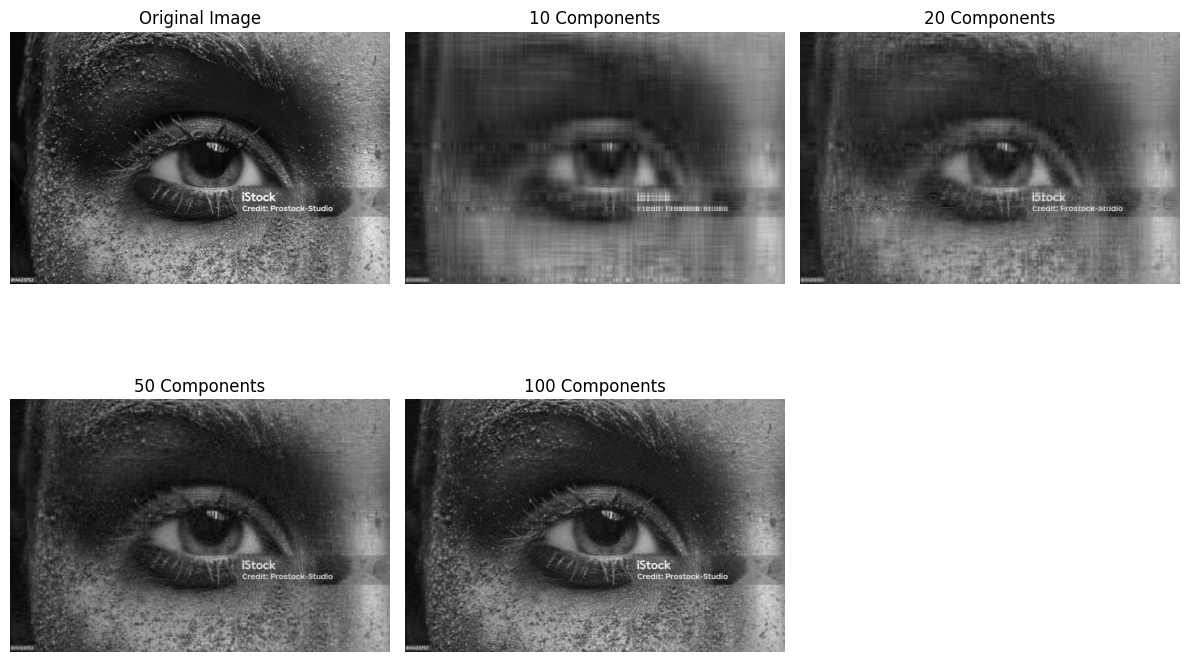

In [75]:
#Display Results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [76]:
#Show Explained Variance for Selected k Values
for k in k_values:
    print(f"k = {k}, Explained Variance = {cumulative_variance[k-1]:.4f}")

k = 10, Explained Variance = 0.8050
k = 20, Explained Variance = 0.8495
k = 50, Explained Variance = 0.9157
k = 100, Explained Variance = 0.9619
